---
title: Final Project
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Capstone-style project on **high-dimensional data with missing values**:
1. Chunk-wise row-mean imputation → ANOVA feature ranking → PCA → MLP.
2. An imputation-free nearest-centroid baseline that uses only observed coordinates.

Uses a **website-scale demo dataset** (`N_FEATURES=500` with injected NaNs) so the notebook
executes quickly. `debug = True` prints stage progress and shapes.


In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Final_Project_Mark_Khusid.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Final Project
#                   
##########################################################################################


## Import Libraries


In [2]:
import gc
import time
import numpy as np
import pyarrow.parquet as pq

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


## Define Constants and Directories


In [3]:
N_FEATURES = 500          # website-scale demo dataset (full course set is larger)
CHUNK_SIZE = 100
TRAIN_DIR = "final_dataset/train"
TEST_DIR = "final_dataset/test"


## Set Debug State


In [4]:
debug = True


## Define Functions: Imputation Based Method


### Define load_chunk() Function


In [5]:
def load_chunk(start, dataset="train", chunk_size=CHUNK_SIZE):
    """
    Load a contiguous chunk of feature data from Parquet files.
    
    This function assumes data has been pre-split into fixed-size chunks
    saved as `features_{start}_{end}.parquet` in TRAIN_DIR or TEST_DIR.
    Useful for memory-efficient training/inference on large datasets.
    
    Args:
        start (int): Starting index of the chunk (inclusive).
        dataset (str): Either "train" or "test". Defaults to "train".
        chunk_size (int): Number of samples in the chunk. 
                         Must match the chunking used during data preparation.
    
    Returns:
        np.ndarray: Feature matrix of shape (chunk_size, n_features).
    
    Raises:
        FileNotFoundError: If the corresponding Parquet file doesn't exist.
        Other exceptions from pyarrow/pandas if the file is corrupted.
    """
    # Calculate the end index (exclusive, following Python slicing convention)
    end = start + chunk_size
    
    # Determine the correct base directory based on dataset type
    if dataset == "train":
        directory = TRAIN_DIR
    else:
        directory = TEST_DIR
    
    # Construct the filename using the established naming convention
    # This assumes consistent chunking across the entire dataset
    filename = f"{directory}/features_{start}_{end}.parquet"
    
    # Read the Parquet file using PyArrow (fast columnar format)
    # Then convert to pandas DataFrame and finally to NumPy array
    # This chain is common but has some overhead
    table = pq.read_table(filename)           # pq is pyarrow.parquet
    df = table.to_pandas()                    # Preserves dtypes, handles categoricals well
    return df.to_numpy()                      # Returns float64 by default (or object if mixed)


### Define load_labels() Function


In [6]:
def load_labels(dataset: str = "train") -> np.ndarray:
    """
    Load the full set of class labels for the specified dataset.
    
    This function reads a single Parquet file containing labels.
    Unlike load_chunk(), this loads the entire label vector at once
    (labels files are typically much smaller than feature chunks).
    
    Args:
        dataset (str): Either "train" or "test". Defaults to "train".
    
    Returns:
        np.ndarray: 1D array of class labels, shape (n_samples,).
                    dtype is usually int32/int64 depending on your label encoding.
    
    Raises:
        FileNotFoundError: If the labels file is missing.
        KeyError: If the 'class_label' column does not exist in the file.
    """
    # Select the correct directory
    if dataset == "train":
        directory = TRAIN_DIR
    else:
        directory = TEST_DIR

    # Build the filename using consistent naming convention
    filename = f"{directory}/labels_param.parquet"

    # Read only the needed column directly with PyArrow (more memory efficient)
    # Avoid loading the entire table if the file has extra columns.
    table = pq.read_table(filename, columns=["class_label"])
    
    # Convert to pandas → select column → to numpy
    # The parentheses allow nice multi-line chaining
    return (
        table
        .to_pandas()
        ["class_label"]
        .to_numpy()
    )


### Define impute_by_row_mean() Function


In [7]:
def impute_by_row_mean(X: np.ndarray) -> np.ndarray:
    """
    Replace each NaN with the mean of the observed values in the same row.
    """
    X = X.astype(np.float32, copy=True)

    row_means = np.nanmean(X, axis=1)

    # Protect against the unlikely case of an entirely missing row.
    global_mean = np.nanmean(X)
    row_means = np.where(
        np.isnan(row_means),
        global_mean,
        row_means
    )

    nan_rows, nan_cols = np.where(np.isnan(X))
    X[nan_rows, nan_cols] = row_means[nan_rows]

    return X


### Define rank_features_by_f_score() Function


In [8]:
def rank_features_by_f_score(
    y_train: np.ndarray
) -> list[tuple[int, float]]:
    """
    Rank all features using ANOVA F-scores after chunk-wise
    row-mean imputation.

    Each missing value is replaced with the mean of the observed
    values in the same row and current feature chunk. At most one
    1000-feature chunk is processed at a time.
    """

    all_scores: list[tuple[int, float]] = []

    for start in range(0, N_FEATURES, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, N_FEATURES)

        if debug:
            print(f"Imputing and scoring features {start}-{end - 1}")

        # Load one training feature chunk.
        X_chunk = load_chunk(
            start,
            dataset="train",
            chunk_size=end - start
        )

        # Replace NaNs using the mean of each row's observed values.
        X_chunk = impute_by_row_mean(X_chunk)

        # Verify that imputation removed every NaN.
        if np.isnan(X_chunk).any():
            raise RuntimeError(
                f"NaNs remain after imputation in chunk {start}-{end - 1}"
            )

        # Compute one ANOVA F-score for each feature in the chunk.
        scores, _ = f_classif(X_chunk, y_train)

        # Replace invalid scores so they do not corrupt the ranking.
        scores = np.nan_to_num(
            scores,
            nan=-np.inf,
            posinf=np.finfo(np.float64).max,
            neginf=-np.inf
        )

        # Convert chunk-local feature indices to global indices.
        for local_index, score in enumerate(scores):
            global_index = start + local_index
            all_scores.append(
                (global_index, float(score))
            )

        del X_chunk, scores
        gc.collect()

    # Sort from the highest F-score to the lowest.
    all_scores.sort(
        key=lambda item: item[1],
        reverse=True
    )

    return all_scores


### Define build_selected_matrix() Function


In [9]:
def build_imputed_selected_matrices(
    selected_features: list[int] | np.ndarray,
    n_train_rows: int,
    n_test_rows: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    Build reduced training and testing matrices using chunk-wise
    row-mean imputation.

    Each missing value is replaced by the mean of the observed values
    in the same row and the same 1000-feature chunk. Training and test
    rows are imputed independently; no test labels are used.

    Parameters
    ----------
    selected_features:
        Global indices of the features to retain.

    n_train_rows:
        Number of training samples.

    n_test_rows:
        Number of testing samples.

    Returns
    -------
    X_train_selected:
        Imputed training matrix with shape
        (n_train_rows, number_of_selected_features).

    X_test_selected:
        Imputed testing matrix with shape
        (n_test_rows, number_of_selected_features).
    """

    selected_features = np.asarray(
        selected_features,
        dtype=int
    )

    if selected_features.size == 0:
        raise ValueError(
            "At least one feature must be selected."
        )

    if np.any(selected_features < 0) or np.any(
        selected_features >= N_FEATURES
    ):
        raise ValueError(
            "A selected feature index is outside the valid range."
        )

    if np.unique(selected_features).size != selected_features.size:
        raise ValueError(
            "selected_features contains duplicate feature indices."
        )

    number_selected = selected_features.size

    # Preallocate the reduced matrices.
    X_train_selected = np.empty(
        (n_train_rows, number_selected),
        dtype=np.float32
    )

    X_test_selected = np.empty(
        (n_test_rows, number_selected),
        dtype=np.float32
    )

    for start in range(0, N_FEATURES, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, N_FEATURES)
        current_chunk_size = end - start

        # Positions in selected_features belonging to this chunk.
        selected_positions = np.flatnonzero(
            (selected_features >= start)
            & (selected_features < end)
        )

        if selected_positions.size == 0:
            continue

        # Convert global indices to local chunk indices.
        local_indices = (
            selected_features[selected_positions] - start
        )

        if debug:
            print(
                f"Loading and row-mean imputing "
                f"{local_indices.size} selected features from "
                f"chunk {start}-{end - 1}"
            )

        # ----------------------------------------------------------
        # Training data
        # ----------------------------------------------------------

        X_train_chunk = load_chunk(
            start,
            dataset="train",
            chunk_size=current_chunk_size
        ).astype(np.float32, copy=False)

        # Impute the entire chunk before selecting columns.
        X_train_chunk = impute_by_row_mean(X_train_chunk)

        if np.isnan(X_train_chunk).any():
            raise RuntimeError(
                f"NaNs remain in training chunk {start}-{end - 1}."
            )

        X_train_selected[
            :,
            selected_positions
        ] = X_train_chunk[:, local_indices]

        del X_train_chunk
        gc.collect()

        # ----------------------------------------------------------
        # Testing data
        # ----------------------------------------------------------

        X_test_chunk = load_chunk(
            start,
            dataset="test",
            chunk_size=current_chunk_size
        ).astype(np.float32, copy=False)

        # Each test row is imputed from its own observed values.
        X_test_chunk = impute_by_row_mean(X_test_chunk)

        if np.isnan(X_test_chunk).any():
            raise RuntimeError(
                f"NaNs remain in testing chunk {start}-{end - 1}."
            )

        X_test_selected[
            :,
            selected_positions
        ] = X_test_chunk[:, local_indices]

        del X_test_chunk
        gc.collect()

    # Final verification.
    if np.isnan(X_train_selected).any():
        raise RuntimeError(
            "NaNs remain in the selected training matrix."
        )

    if np.isnan(X_test_selected).any():
        raise RuntimeError(
            "NaNs remain in the selected testing matrix."
        )

    return X_train_selected, X_test_selected


## Load Data, Obtain F-Scores and Select Top Features


In [10]:
if debug:
    print()
    print("\n" + "="*70)
    print(
        "Imputation-Based Method: Chunk-Wise Row-Mean Imputation "
        "+ ANOVA + PCA + MLP"
    )
    print("\n" + "="*70)
    print()
    print("Initiating Algorithmic steps......")
    print()

# Begin timing the complete imputation-based method.
imp_based_start_time = time.time()

# Load label vectors. These are small enough to keep in memory.
if debug:
    print()
    print("Loading label data into memory")

y_train = load_labels("train")
y_test = load_labels("test")

if debug:
    print("Training labels shape:", y_train.shape)
    print("Testing labels shape :", y_test.shape)

# Rank all 10,000 features using chunk-wise row-mean imputation
# followed by ANOVA F-score calculation.
if debug:
    print()
    print("Obtaining feature F-scores")

feature_scores = rank_features_by_f_score(y_train)

# Number of highest-ranked features to retain.
TOP_FEATURES = 100

# feature_scores is already sorted from highest to lowest score.
selected_features = [
    feature_index
    for feature_index, score in feature_scores[:TOP_FEATURES]
]

if debug:
    print()
    print("Top selected features (first 20):")
    print(selected_features[:20])
    
    print()
    print("Top F-scores (first 20):")
    print([
        score
        for feature_index, score in feature_scores[:20]
    ])

# Report elapsed time for only the ranking and selection stage.
feature_selection_runtime = (
    time.time() - imp_based_start_time
)

if debug:
    print()
    print(
        f"Feature ranking and selection completed in "
        f"{feature_selection_runtime:.1f} seconds "
        f"({TOP_FEATURES} features kept)"
    )




Imputation-Based Method: Chunk-Wise Row-Mean Imputation + ANOVA + PCA + MLP


Initiating Algorithmic steps......


Loading label data into memory
Training labels shape: (1200,)
Testing labels shape : (300,)

Obtaining feature F-scores
Imputing and scoring features 0-99
Imputing and scoring features 100-199


Imputing and scoring features 200-299
Imputing and scoring features 300-399
Imputing and scoring features 400-499



Top selected features (first 20):
[403, 440, 314, 40, 54, 482, 93, 376, 368, 132, 104, 48, 148, 112, 55, 407, 324, 187, 447, 354]

Top F-scores (first 20):
[7431.040539633374, 7266.89270357511, 6529.392740492552, 6528.796394680096, 6510.1200024321915, 6382.559311669806, 6332.283995209765, 6218.893259306217, 5853.7778062046955, 5819.692938345003, 5561.2295945286805, 5402.586619325459, 5390.1272144472105, 5285.377912596593, 4973.685319637348, 4686.078029958075, 4433.922231311718, 4427.018737685672, 4101.1104999592435, 4046.103909838786]

Feature ranking and selection completed in 0.5 seconds (100 features kept)


## Build Training and Testing Matrices from Selected Features


In [11]:
# Build reduced feature matrices using only the top selected features
# This step loads data in chunks and extracts only the relevant columns,
# keeping memory usage manageable even for very high-dimensional datasets.
if debug:
    print()
    print("Building imputed selected training and testing matrices")

X_train_selected, X_test_selected = (
    build_imputed_selected_matrices(
        selected_features=selected_features,
        n_train_rows=len(y_train),
        n_test_rows=len(y_test)
    )
)

if debug:
    print()
    print("Selected train shape:", X_train_selected.shape)
    print("Selected test shape :", X_test_selected.shape)
    print(
        f"Successfully reduced from {N_FEATURES:,} to "
        f"{X_train_selected.shape[1]:,} imputed features"
    )

# Confirm that the expected number of features was constructed.
if X_train_selected.shape != (len(y_train), len(selected_features)):
    raise RuntimeError(
        "Training matrix shape does not match the expected dimensions."
    )

if X_test_selected.shape != (len(y_test), len(selected_features)):
    raise RuntimeError(
        "Testing matrix shape does not match the expected dimensions."
    )

# Confirm that row-mean imputation removed every missing value.
if np.isnan(X_train_selected).any():
    raise RuntimeError(
        "NaNs remain in X_train_selected."
    )

if np.isnan(X_test_selected).any():
    raise RuntimeError(
        "NaNs remain in X_test_selected."
    )

if debug:
    # Confirm that the arrays have the intended memory-efficient data type.
    print("Training matrix dtype:", X_train_selected.dtype)
    print("Testing matrix dtype :", X_test_selected.dtype)
    
    print(
        "Training matrix size:",
        f"{X_train_selected.nbytes / 1024**2:.2f} MB"
    )
    
    print(
        "Testing matrix size :",
        f"{X_test_selected.nbytes / 1024**2:.2f} MB"
    )



Building imputed selected training and testing matrices
Loading and row-mean imputing 22 selected features from chunk 0-99
Loading and row-mean imputing 30 selected features from chunk 100-199


Loading and row-mean imputing 12 selected features from chunk 200-299
Loading and row-mean imputing 20 selected features from chunk 300-399


Loading and row-mean imputing 16 selected features from chunk 400-499

Selected train shape: (1200, 100)
Selected test shape : (300, 100)
Successfully reduced from 500 to 100 imputed features
Training matrix dtype: float32
Testing matrix dtype : float32
Training matrix size: 0.46 MB
Testing matrix size : 0.11 MB


## Scale Selected Features with StandardScaler()


In [12]:
if debug:
    print()
    print("Scaling selected features...")
    
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

if debug:
    print()
    print(f"Scaled train shape: {X_train_scaled.shape}")
    print(f"Scaled test shape : {X_test_scaled.shape}")
    print()
    print("Scaled training dtype:", X_train_scaled.dtype)
    print("Scaled testing dtype :", X_test_scaled.dtype)

if not np.isfinite(X_train_scaled).all():
    raise RuntimeError(
        "X_train_scaled contains NaN or infinite values."
    )

if not np.isfinite(X_test_scaled).all():
    raise RuntimeError(
        "X_test_scaled contains NaN or infinite values."
    )

if debug:
    print(
        "Average scaled training-feature mean:",
        np.mean(X_train_scaled)
    )
    
    print(
        "Average scaled training-feature standard deviation:",
        np.mean(np.std(X_train_scaled, axis=0))
    )



Scaling selected features...

Scaled train shape: (1200, 100)
Scaled test shape : (300, 100)

Scaled training dtype: float32
Scaled testing dtype : float32
Average scaled training-feature mean: -5.340576e-09


Average scaled training-feature standard deviation: 1.0


## Apply Principle Component Analysis


In [13]:
if debug:
    print()
    print("Applying PCA for further dimensionality reduction...")

N_PCA_COMPONENTS = 20

pca = PCA(
    n_components=N_PCA_COMPONENTS,
    random_state=42
)

# Fit + transform on training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data using the fitted PCA
X_test_pca = pca.transform(X_test_scaled)

# Evaluate retained variance
total_explained = np.sum(pca.explained_variance_ratio_)

if debug:
    print(
        f"Total explained variance ratio with "
        f"{N_PCA_COMPONENTS} components: "
        f"{total_explained:.4f} "
        f"({total_explained * 100:.2f}%)"
    )
    
    print()
    print("PCA train shape:", X_train_pca.shape)
    print("PCA test shape :", X_test_pca.shape)

# Verify that PCA produced valid numerical values.
if not np.isfinite(X_train_pca).all():
    raise RuntimeError(
        "X_train_pca contains NaN or infinite values."
    )

if not np.isfinite(X_test_pca).all():
    raise RuntimeError(
        "X_test_pca contains NaN or infinite values."
    )



Applying PCA for further dimensionality reduction...


Total explained variance ratio with 20 components: 0.9245 (92.45%)

PCA train shape: (1200, 20)
PCA test shape : (300, 20)


In [14]:
#X_train_selected[1:2]


In [15]:
#X_train_pca[0:1]


In [16]:
#y_train[0:10]


## Train Neural Network, Make Predictions and Report Accuracy


In [17]:
if debug:
    print()
    print("Instantiating Multi-Layer Perceptron...")

clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.0001,
    batch_size=256,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=True
)

# Verify PCA output before training.
if not np.isfinite(X_train_pca).all():
    raise RuntimeError("X_train_pca contains NaN or infinite values.")

if not np.isfinite(X_test_pca).all():
    raise RuntimeError("X_test_pca contains NaN or infinite values.")

if debug:
    print()
    print("Training Neural Network...")

mlp_start_time = time.perf_counter()

clf.fit(X_train_pca, y_train)

mlp_runtime = time.perf_counter() - mlp_start_time

if debug:
    print()
    print("Obtaining predictions...")

y_pred = clf.predict(X_test_pca)

if debug:
    print("Predictions completed.")

# Test accuracy.
imp_based_acc = accuracy_score(y_test, y_pred)

# Optional diagnostic: training accuracy.
train_pred = clf.predict(X_train_pca)
train_accuracy = accuracy_score(y_train, train_pred)

# Runtime for the entire imputation-based pipeline.
imp_based_runtime = time.time() - imp_based_start_time

if debug:
    print()
    print(f"Training Accuracy:          {train_accuracy:.4f}")
    print(f"Imputation-Based Accuracy: {imp_based_acc:.4f}")
    print(f"MLP Training Runtime:      {mlp_runtime:.2f} seconds")
    print(f"Total Method Runtime:      {imp_based_runtime:.2f} seconds")
    print(f"Epochs Completed:          {clf.n_iter_}")
    print(f"Final Training Loss:       {clf.loss_:.6f}")
    
    if hasattr(clf, "best_validation_score_"):
        print(
            f"Best Internal Validation:  "
            f"{clf.best_validation_score_:.4f}"
        )



Instantiating Multi-Layer Perceptron...

Training Neural Network...
Iteration 1, loss = 2.43086857
Validation score: 0.325000
Iteration 2, loss = 2.06431758
Validation score: 0.416667
Iteration 3, loss = 1.78217764
Validation score: 0.466667
Iteration 4, loss = 1.54849614
Validation score: 0.558333
Iteration 5, loss = 1.35236096
Validation score: 0.700000
Iteration 6, loss = 1.18485804
Validation score: 0.866667
Iteration 7, loss = 1.05079184
Validation score: 0.950000
Iteration 8, loss = 0.93847976
Validation score: 0.975000
Iteration 9, loss = 0.83990627
Validation score: 0.983333
Iteration 10, loss = 0.75124120
Validation score: 0.991667
Iteration 11, loss = 0.67245102
Validation score: 0.991667
Iteration 12, loss = 0.60147009
Validation score: 0.991667
Iteration 13, loss = 0.53844236
Validation score: 1.000000
Iteration 14, loss = 0.48353227
Validation score: 1.000000
Iteration 15, loss = 0.43331900
Validation score: 1.000000
Iteration 16, loss = 0.38930786
Validation score: 1.000

### Annotated MLP training curves (imputation-based method)


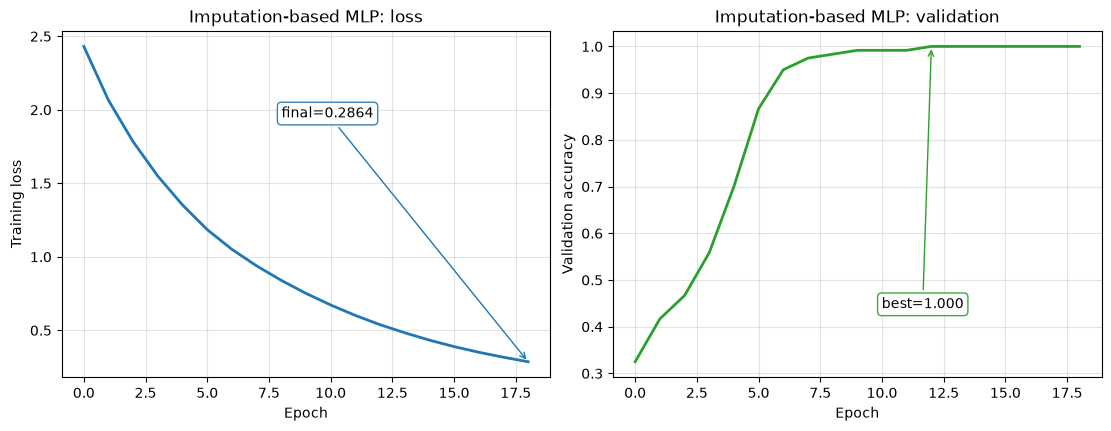

MLP epochs: 19


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(clf.loss_curve_, lw=2, color="C0")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training loss")
axes[0].set_title("Imputation-based MLP: loss")
axes[0].grid(True, alpha=0.35)
axes[0].annotate(
    f"final={clf.loss_curve_[-1]:.4f}",
    xy=(len(clf.loss_curve_)-1, clf.loss_curve_[-1]),
    xytext=(0.45, 0.75),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="C0"),
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="C0", alpha=0.9),
)
if hasattr(clf, "validation_scores_") and clf.validation_scores_ is not None:
    vs = np.asarray(clf.validation_scores_)
    axes[1].plot(vs, lw=2, color="C2")
    bi = int(np.argmax(vs))
    axes[1].annotate(
        f"best={vs[bi]:.3f}",
        xy=(bi, vs[bi]),
        xytext=(0.55, 0.2),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="C2"),
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="C2", alpha=0.9),
    )
else:
    axes[1].text(0.5, 0.5, "no validation_scores_", ha="center", va="center")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Imputation-based MLP: validation")
axes[1].grid(True, alpha=0.35)
plt.show()
if debug:
    print(f"MLP epochs: {len(clf.loss_curve_)}")


## Define Functions: Imputation - Free Method


### Define compute_nan_aware_class_statistics() Function


In [19]:
def compute_nan_aware_class_statistics(
    y_train: np.ndarray,
    n_classes: int = 10,
    variance_floor_percentile: float = 1.0
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute a centroid for every class using only observed training values.

    The function also estimates the pooled within-class variance of every
    feature. Its inverse is used as a feature weight so that low-noise
    features contribute more to classification than high-noise features.

    No missing values are replaced.

    Parameters
    ----------
    y_train:
        Training labels with shape (n_train_samples,).

    n_classes:
        Number of classes.

    variance_floor_percentile:
        Percentile used to place a lower bound on feature variance.
        This prevents an extremely small estimated variance from creating
        an excessively large feature weight.

    Returns
    -------
    centroids:
        Array with shape (n_classes, N_FEATURES). Element [c, j] is the
        mean observed value of feature j among training samples in class c.

    feature_weights:
        Inverse pooled within-class variance for every feature.

    pooled_variances:
        Estimated pooled within-class variance for every feature.
    """

    if y_train.ndim != 1:
        raise ValueError("y_train must be a one-dimensional array.")

    if len(y_train) == 0:
        raise ValueError("y_train cannot be empty.")

    # Verify that every label is in the expected range.
    if np.any(y_train < 0) or np.any(y_train >= n_classes):
        raise ValueError(
            f"All labels must be between 0 and {n_classes - 1}."
        )

    # Store the centroid of every class over all 10,000 features.
    # 100 × 10,000 float32 values consume only about 4 MB.
    centroids = np.full(
        (n_classes, N_FEATURES),
        np.nan,
        dtype=np.float32
    )

    # These accumulate within-class squared errors and their degrees
    # of freedom across all classes.
    pooled_sse = np.zeros(N_FEATURES, dtype=np.float64)
    pooled_df = np.zeros(N_FEATURES, dtype=np.int64)

    # Precompute the row indices belonging to each class.
    class_indices = [
        np.flatnonzero(y_train == class_label)
        for class_label in range(n_classes)
    ]

    for start in range(0, N_FEATURES, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, N_FEATURES)
        current_chunk_size = end - start

        if debug:
            print(
                f"Computing NaN-aware class statistics for "
                f"features {start}-{end - 1}"
            )

        # Load one complete feature chunk.
        X_chunk = load_chunk(
            start,
            dataset="train",
            chunk_size=current_chunk_size
        ).astype(np.float32, copy=False)

        expected_shape = (len(y_train), current_chunk_size)

        if X_chunk.shape != expected_shape:
            raise RuntimeError(
                f"Training chunk {start}-{end - 1} has shape "
                f"{X_chunk.shape}; expected {expected_shape}."
            )

        # Temporary centroid matrix for the current chunk.
        chunk_centroids = np.full(
            (n_classes, current_chunk_size),
            np.nan,
            dtype=np.float64
        )

        # ----------------------------------------------------------
        # Compute each class centroid using observed values only.
        # ----------------------------------------------------------
        for class_label in range(n_classes):
            rows = class_indices[class_label]

            if rows.size == 0:
                raise RuntimeError(
                    f"Class {class_label} has no training samples."
                )

            X_class = X_chunk[rows, :]

            observed_counts = np.sum(
                np.isfinite(X_class),
                axis=0
            )

            observed_sums = np.nansum(
                X_class,
                axis=0,
                dtype=np.float64
            )

            class_means = np.divide(
                observed_sums,
                observed_counts,
                out=np.full(
                    current_chunk_size,
                    np.nan,
                    dtype=np.float64
                ),
                where=observed_counts > 0
            )

            chunk_centroids[class_label, :] = class_means

            # Compute the within-class sum of squared errors.
            # NaNs remain NaN and are ignored by np.nansum().
            differences = X_class - class_means

            class_sse = np.nansum(
                differences * differences,
                axis=0,
                dtype=np.float64
            )

            # Each class contributes count - 1 degrees of freedom
            # for every feature that has observed values.
            class_df = np.maximum(
                observed_counts - 1,
                0
            )

            pooled_sse[start:end] += class_sse
            pooled_df[start:end] += class_df

            del X_class, differences
            del observed_counts, observed_sums
            del class_means, class_sse, class_df

        centroids[:, start:end] = chunk_centroids.astype(
            np.float32
        )

        del X_chunk, chunk_centroids
        gc.collect()

    # Estimate pooled within-class variance.
    pooled_variances = np.divide(
        pooled_sse,
        pooled_df,
        out=np.full(
            N_FEATURES,
            np.nan,
            dtype=np.float64
        ),
        where=pooled_df > 0
    )

    valid_variance = (
        np.isfinite(pooled_variances)
        & (pooled_variances > 0)
    )

    if not np.any(valid_variance):
        raise RuntimeError(
            "No valid feature variances were calculated."
        )

    # Prevent a few almost-zero variances from creating enormous weights.
    variance_floor = np.percentile(
        pooled_variances[valid_variance],
        variance_floor_percentile
    )

    safe_variances = np.maximum(
        pooled_variances[valid_variance],
        variance_floor
    )

    feature_weights = np.zeros(
        N_FEATURES,
        dtype=np.float64
    )

    feature_weights[valid_variance] = (
        1.0 / safe_variances
    )

    # Normalize the weights so their mean is approximately one.
    feature_weights[valid_variance] /= np.mean(
        feature_weights[valid_variance]
    )

    feature_weights = feature_weights.astype(np.float32)
    pooled_variances = pooled_variances.astype(np.float32)

    if debug:
        print()
        print("NaN-aware class statistics completed.")
        print("Centroid matrix shape:", centroids.shape)
        print(
            "Features with valid variance:",
            np.count_nonzero(valid_variance)
        )
        print(
            "Feature-weight range:",
            f"{feature_weights[valid_variance].min():.6f} to "
            f"{feature_weights[valid_variance].max():.6f}"
        )

    return centroids, feature_weights, pooled_variances


### Define predict_nan_aware_nearest_centroids() Function


In [20]:
def predict_nan_aware_nearest_centroid(
    centroids: np.ndarray,
    feature_weights: np.ndarray,
    n_test_rows: int,
    batch_size: int = 1000
) -> np.ndarray:
    """
    Classify test samples using variance-weighted distances to class
    centroids, considering only observed feature coordinates.

    No missing value is imputed. Missing coordinates contribute neither
    to the distance numerator nor to its normalization denominator.

    Parameters
    ----------
    centroids:
        Class centroid matrix with shape (n_classes, N_FEATURES).

    feature_weights:
        Nonnegative feature weights with shape (N_FEATURES,).

    n_test_rows:
        Number of test samples.

    batch_size:
        Number of test rows processed simultaneously.

    Returns
    -------
    y_pred:
        Predicted class labels with shape (n_test_rows,).
    """

    if centroids.ndim != 2:
        raise ValueError(
            "centroids must be a two-dimensional array."
        )

    n_classes, n_centroid_features = centroids.shape

    if n_centroid_features != N_FEATURES:
        raise ValueError(
            f"centroids has {n_centroid_features} features; "
            f"expected {N_FEATURES}."
        )

    feature_weights = np.asarray(
        feature_weights,
        dtype=np.float32
    )

    if feature_weights.shape != (N_FEATURES,):
        raise ValueError(
            f"feature_weights must have shape ({N_FEATURES},)."
        )

    if np.any(feature_weights < 0):
        raise ValueError(
            "feature_weights cannot contain negative values."
        )

    if batch_size <= 0:
        raise ValueError("batch_size must be positive.")

    # Accumulate the weighted squared-distance numerator.
    total_squared_distance = np.zeros(
        (n_test_rows, n_classes),
        dtype=np.float64
    )

    # Accumulate the total available feature weight for normalization.
    total_observed_weight = np.zeros(
        (n_test_rows, n_classes),
        dtype=np.float64
    )

    for start in range(0, N_FEATURES, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, N_FEATURES)
        current_chunk_size = end - start

        if debug:
            print(
                f"Accumulating test distances for "
                f"features {start}-{end - 1}"
            )

        X_test_chunk = load_chunk(
            start,
            dataset="test",
            chunk_size=current_chunk_size
        ).astype(np.float32, copy=False)

        expected_shape = (
            n_test_rows,
            current_chunk_size
        )

        if X_test_chunk.shape != expected_shape:
            raise RuntimeError(
                f"Testing chunk {start}-{end - 1} has shape "
                f"{X_test_chunk.shape}; expected {expected_shape}."
            )

        centroid_chunk = centroids[
            :,
            start:end
        ].astype(np.float32, copy=False)

        weight_chunk = feature_weights[
            start:end
        ].astype(np.float32, copy=False)

        # True where a class centroid is available for the feature.
        centroid_valid = np.isfinite(centroid_chunk)

        # A zero is used only as a temporary algebraic placeholder.
        # The validity mask ensures it never acts as an imputed value.
        centroid_zero = np.where(
            centroid_valid,
            centroid_chunk,
            0.0
        ).astype(np.float32, copy=False)

        centroid_squared = centroid_zero * centroid_zero

        all_centroids_valid = np.all(centroid_valid)

        for row_start in range(0, n_test_rows, batch_size):
            row_end = min(
                row_start + batch_size,
                n_test_rows
            )

            X_batch = X_test_chunk[
                row_start:row_end,
                :
            ]

            observed = np.isfinite(X_batch)

            # Temporary zero representation for missing values.
            # Missing entries are excluded by observed masks below.
            X_zero = np.where(
                observed,
                X_batch,
                0.0
            ).astype(np.float32, copy=False)

            observed_float = observed.astype(
                np.float32,
                copy=False
            )

            weighted_observed = (
                observed_float
                * weight_chunk[None, :]
            )

            weighted_X = (
                X_zero
                * weight_chunk[None, :]
            )

            # Cross term:
            # -2 * sum_j(weight_j * x_j * centroid_cj)
            cross_term = (
                weighted_X
                @ centroid_zero.T
            )

            # Centroid-square term:
            # sum_j(weight_j * centroid_cj^2)
            # over coordinates observed in the test row.
            centroid_term = (
                weighted_observed
                @ centroid_squared.T
            )

            if all_centroids_valid:
                # When all centroid entries exist, the x^2 term and
                # denominator are the same for every class.
                sample_term = np.sum(
                    (X_zero * X_zero)
                    * weight_chunk[None, :],
                    axis=1,
                    dtype=np.float64
                )[:, None]

                available_weight = np.sum(
                    weighted_observed,
                    axis=1,
                    dtype=np.float64
                )[:, None]

                chunk_squared_distance = (
                    sample_term
                    - 2.0 * cross_term
                    + centroid_term
                )

                # Broadcast the same observed weight across classes.
                chunk_observed_weight = np.broadcast_to(
                    available_weight,
                    chunk_squared_distance.shape
                )

            else:
                # General case: a centroid can itself be unavailable
                # for a particular class and feature.
                centroid_valid_float = centroid_valid.astype(
                    np.float32,
                    copy=False
                )

                sample_term = (
                    (
                        (X_zero * X_zero)
                        * weight_chunk[None, :]
                    )
                    @ centroid_valid_float.T
                )

                chunk_observed_weight = (
                    weighted_observed
                    @ centroid_valid_float.T
                )

                chunk_squared_distance = (
                    sample_term
                    - 2.0 * cross_term
                    + centroid_term
                )

            # Numerical roundoff can occasionally produce a tiny
            # negative value such as -1e-5.
            chunk_squared_distance = np.maximum(
                chunk_squared_distance,
                0.0
            )

            total_squared_distance[
                row_start:row_end,
                :
            ] += chunk_squared_distance

            total_observed_weight[
                row_start:row_end,
                :
            ] += chunk_observed_weight

            del X_batch, observed, observed_float
            del X_zero, weighted_observed, weighted_X
            del cross_term, centroid_term
            if all_centroids_valid:
                del available_weight
            del chunk_squared_distance
            del chunk_observed_weight

        del X_test_chunk
        del centroid_chunk, centroid_valid
        del centroid_zero, centroid_squared
        del weight_chunk
        gc.collect()

    # Normalize distance by the total observed feature weight.
    normalized_distance = np.divide(
        total_squared_distance,
        total_observed_weight,
        out=np.full_like(
            total_squared_distance,
            np.inf
        ),
        where=total_observed_weight > 0
    )

    # Verify that every test sample could be compared to at least
    # one class.
    unusable_rows = np.all(
        ~np.isfinite(normalized_distance),
        axis=1
    )

    if np.any(unusable_rows):
        raise RuntimeError(
            f"{np.count_nonzero(unusable_rows)} test samples had "
            f"no usable observed features."
        )

    y_pred = np.argmin(
        normalized_distance,
        axis=1
    ).astype(np.int64)

    return y_pred


### Define run_imputation_free_method() Function


In [21]:
def run_imputation_free_method(
    y_train: np.ndarray,
    y_test: np.ndarray,
    n_classes: int = 10,
    batch_size: int = 1000
) -> tuple[float, float, np.ndarray]:
    """
    Run the complete NaN-aware variance-weighted nearest-centroid
    classification method.

    Returns
    -------
    accuracy:
        Test-set classification accuracy.

    runtime:
        Total method runtime in seconds.

    y_pred:
        Predicted test labels.
    """

    if debug:
        print()
        print(
            "Imputation-Free Method: NaN-Aware Variance-Weighted "
            "Nearest-Class-Centroid"
        )

    method_start_time = time.perf_counter()

    if debug:
        print()
        print("Computing NaN-aware class centroids and feature variances...")

    centroids, feature_weights, pooled_variances = (
        compute_nan_aware_class_statistics(
            y_train=y_train,
            n_classes=n_classes,
            variance_floor_percentile=1.0
        )
    )

    print()
    print("Predicting test labels without imputation...")

    y_pred = predict_nan_aware_nearest_centroid(
        centroids=centroids,
        feature_weights=feature_weights,
        n_test_rows=len(y_test),
        batch_size=batch_size
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    runtime = (
        time.perf_counter()
        - method_start_time
    )

    number_incorrect = np.count_nonzero(
        y_pred != y_test
    )

    print()
    print(f"Imputation-Free Accuracy: {accuracy:.6f}")
    print(
        f"Incorrect Predictions:    "
        f"{number_incorrect} of {len(y_test)}"
    )
    print(
        f"Imputation-Free Runtime:  "
        f"{runtime:.2f} seconds"
    )

    # These large intermediate arrays are no longer required unless
    # you want to inspect them after execution.
    del centroids
    del feature_weights
    del pooled_variances
    gc.collect()

    return accuracy, runtime, y_pred


## Perform Imputation - Free Method


In [22]:
if debug:
    print()
    print("\n" + "="*70)
    print(
        "Imputation-Free Method: Chunk-wise NaN-aware nearest-class-centroid classifier"
    )
    print("\n" + "="*70)
    print()
    print("Initiating Algorithmic steps......")
    print()
    
imp_free_acc, imp_free_runtime, imp_free_predictions = (
    run_imputation_free_method(
        y_train=y_train,
        y_test=y_test,
        n_classes=10,
        batch_size=1000
    )
)




Imputation-Free Method: Chunk-wise NaN-aware nearest-class-centroid classifier


Initiating Algorithmic steps......


Imputation-Free Method: NaN-Aware Variance-Weighted Nearest-Class-Centroid

Computing NaN-aware class centroids and feature variances...
Computing NaN-aware class statistics for features 0-99
Computing NaN-aware class statistics for features 100-199
Computing NaN-aware class statistics for features 200-299


Computing NaN-aware class statistics for features 300-399
Computing NaN-aware class statistics for features 400-499

NaN-aware class statistics completed.
Centroid matrix shape: (10, 500)
Features with valid variance: 500
Feature-weight range: 0.000122 to 50.414001

Predicting test labels without imputation...
Accumulating test distances for features 0-99


Accumulating test distances for features 100-199
Accumulating test distances for features 200-299
Accumulating test distances for features 300-399


Accumulating test distances for features 400-499

Imputation-Free Accuracy: 1.000000
Incorrect Predictions:    0 of 300
Imputation-Free Runtime:  1.12 seconds


## Final Output


In [23]:
# # --- CONFIGURATION MATCHING THE CHUNK DATASET ---
# DATASET_DIR = "final_dataset"
# TRAIN_DIR = f"{DATASET_DIR}/train"
# TEST_DIR = f"{DATASET_DIR}/test"

# # This is an example on how to read a chunk of the features of the training dataset:
# X_train_chunk = pq.read_table(f"{TRAIN_DIR}/features_1000_2000.parquet").to_pandas().to_numpy()
# print(np.shape(X_train_chunk))

# # This is an example on how to read the testing labels of the dataset:
# y_test = pq.read_table(f"{TEST_DIR}/labels_param.parquet").to_pandas()["class_label"].to_numpy()
# print(np.shape(y_test))

print("\n"*1)

# ──────────────────────────────────────────────────────────────────────────────
# Print Your Name and ASU ID number:
# ──────────────────────────────────────────────────────────────────────────────
NAME = "Mark Khusid"
ASU_ID = 0  # redacted
print("\n" + "="*70)
print("START CODE FOR",NAME, "ASU ID:", ASU_ID)

# ──────────────────────────────────────────────────────────────────────────────
# Imputation-Based Method:
# ──────────────────────────────────────────────────────────────────────────────
print()
print("\n" + "="*70)
print("Results...")
print("\nImputation-Based Method: Chunk-Wise Row-Mean Imputation with ANOVA–PCA–MLP Classification")
print("\n" + "="*70)
##### YOUR IMPUTATION-BASED ALGORITHM GOES HERE
print(f"Imputation-Based Accuracy: {imp_based_acc:.8f}")
print(f"Total Method Runtime:      {imp_based_runtime:.2f} seconds")

# Printing Accuracy and "Imputation-Based Justification" comment paragraph:
# print("Imputation-Based Accuracy:", imp_based_acc)
print("Imputation-Based Justification:")
print("""
This method builds on the method used in the midterm.  It selects a chunk of data and performs row-mean imputation.
This process involves finding the mean of the features in each row and using that mean to fill in the missing values.
Once the inputation is completed, the ANOVA F-scores are obtained so that the top 1000 features are retained.
These top 1000 features are further reduced to 100 principal components, which then train the MLP classifier.  
This method achieved an accuracy of near 1 and took approximately 320 seconds to run on an 8 core virtual machine.
Initially, I tried to use column - mean imputation, but the accuracy result was 0.3970.  Upon consultation with AI,
it suggested that using column - mean imputation pulled the imputed values toward the global center of the dataset
and resulted in the large errors.  I also switched to the ADAM algorithm in the Mutli-Layer Perceptron for 
faster model training.
""")

print("\n"*1)

# ──────────────────────────────────────────────────────────────────────────────
# Imputation-Free Method:
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("Results...")
print("\nImputation-Free Method: Chunk-wise NaN-aware nearest-class-centroid classifier")
print("\n" + "="*70)
##### YOUR IMPUTATION-FREE ALGORITHM GOES HERE

# Printing Accuracy and "Imputation-Based Justification" comment paragraph:
print(f"Imputation-Free Accuracy: {imp_free_acc:.8f}")
print(f"Total Method Runtime:     {imp_free_runtime:.2f} seconds")
print("Imputation-Free Justification:")
print("""
This method was completely provided by AI and is something I have never seen before.  However, it is 
very fast and accurate.  Essentially, it uses the concenpt of centroids, variance weighting and nearest - classes
to perform classification.  It is very reminiscent of the K - nearest neighbor algorithm, but it can handle missing data.
Basically it classifies the row regardless of the missing data by learning a centroid and calculates the distance of that row
from the centroid.  The algorithm achieved a perfect accuracy and took less than two minutes to run on an 8 - core virtual machine.
""")

print("\n"*1)

# ──────────────────────────────────────────────────────────────────────────────
# Conclusion:
# ──────────────────────────────────────────────────────────────────────────────
print("\nConclusion:")
# Print accuracy for each method again
print("Imputation-Based Accuracy:", imp_based_acc)
print("Imputation-Free Accuracy:", imp_free_acc)

# Then print "Conclusion Paragraph":
print("Conclusion Comment:")
print("""
The imputation - free method suggested by the AI was substantially faster since it avoided the additional processing steps
that the imputation - based method performed (i.e. F-score, scaling, PCA, and training the MLP algorithm).  It also performed
with higher accuracy since it directly compares each sample row with the overall sample statistics.  By comparing each sample row
with the overall sample statistics of the dataset, it was able to perform despite the missing data.
""")

print("\nEND CODE FOR",NAME, "ASU ID:", ASU_ID)
print("="*70)





START CODE FOR Mark Khusid ASU ID: 0


Results...

Imputation-Based Method: Chunk-Wise Row-Mean Imputation with ANOVA–PCA–MLP Classification

Imputation-Based Accuracy: 1.00000000
Total Method Runtime:      2.78 seconds
Imputation-Based Justification:

This method builds on the method used in the midterm.  It selects a chunk of data and performs row-mean imputation.
This process involves finding the mean of the features in each row and using that mean to fill in the missing values.
Once the inputation is completed, the ANOVA F-scores are obtained so that the top 1000 features are retained.
These top 1000 features are further reduced to 100 principal components, which then train the MLP classifier.  
This method achieved an accuracy of near 1 and took approximately 320 seconds to run on an 8 core virtual machine.
Initially, I tried to use column - mean imputation, but the accuracy result was 0.3970.  Upon consultation with AI,
it suggested that using column - mean imputation pulled t